# CS485 Homework 1: Exploratory Data Analysis

## Part 0: Introduction & Data Setup

**Dataset Chosen:** Multimodal Universe - SDSS Galaxy Catalog

**Selected Modalities:**
For this analysis, two modalities are integrated:
1. **Photometric Data:** 5 broad-band magnitudes (u, g, r, i, z) capturing overall brightness.
2. **Spectral Data:** 5 spectral line equivalent widths (H-alpha, OIII etc..) providing chemical composition.

**Data Matrix Definition ($X$):**
The dataset is represented as a data matrix $X \in \mathbb{R}^{n \times d}$. 
* **$n$ (Samples):** Represents 1000 distinct galaxies.
* **$d$ (Features):** 10 combined features (5 photometric + 5 spectral).
* Therefore, $X \in \mathbb{R}^{1000 \times 10}$.

**Target Vector ($y$):**
The target vector $y \in \mathbb{R}^{n}$ represents the spectroscopic redshift of each galaxy.

In [1]:
#fundamental library imports
import numpy as np
import pandas as pd

#plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns

#tools for scaling and similarity
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler

#matplotlib config for inline plots
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid') #specify style

from datasets import load_dataset

#download the SDSS dataset and convert to pandas dataframe
dataset = load_dataset('MultimodalUniverse/sdss', split='train[:1000]')
df = dataset.to_pandas()

#save the dataframe to a local CSV
csv_filename = 'sdss_data.csv'
df.to_csv(csv_filename, index=False)

print(f"Dataset shape: {df.shape}")
print(f"Saved locally as: {csv_filename}")

## Part 1 — Exploratory Data Analysis

### 3.1 Data Encoding & Representation
To begin with the analysis, we need to load the dataset, pinpoint the dataset column names, construct the feature matrix $X$ and extract the target vector $y$.

In [2]:
#load the dataset downloaded from github
df = pd.read_csv('sdss_data.csv')

#print all column names in dataset
print(df.columns.tolist())
#look at the first 3 rows to see what the data actually is
display(df.head(3))

#the csv has columns for magnitudes, spectral lines and redshift
#drop the target column to create the feature matrix X
X_df = df.drop(columns = ['Z'])
y = df['Z'].values

#convert to numpy array for matrix operations
X = X_df.values

print(f"Shape of Data Matrix X: {X.shape}")
print(f"Shape of Target Vector y: {y.shape}")

['spectrum', 'VDISP', 'VDISP_ERR', 'Z', 'Z_ERR', 'ZWARNING', 'SPECTROFLUX_U', 'SPECTROFLUX_G', 'SPECTROFLUX_R', 'SPECTROFLUX_I', 'SPECTROFLUX_Z', 'SPECTROFLUX_IVAR_U', 'SPECTROFLUX_IVAR_G', 'SPECTROFLUX_IVAR_R', 'SPECTROFLUX_IVAR_I', 'SPECTROFLUX_IVAR_Z', 'SPECTROSYNFLUX_U', 'SPECTROSYNFLUX_G', 'SPECTROSYNFLUX_R', 'SPECTROSYNFLUX_I', 'SPECTROSYNFLUX_Z', 'SPECTROSYNFLUX_IVAR_U', 'SPECTROSYNFLUX_IVAR_G', 'SPECTROSYNFLUX_IVAR_R', 'SPECTROSYNFLUX_IVAR_I', 'SPECTROSYNFLUX_IVAR_Z', 'object_id']


,spectrum,VDISP,VDISP_ERR,Z,Z_ERR,ZWARNING,SPECTROFLUX_U,SPECTROFLUX_G,SPECTROFLUX_R,SPECTROFLUX_I,...,SPECTROSYNFLUX_G,SPECTROSYNFLUX_R,SPECTROSYNFLUX_I,SPECTROSYNFLUX_Z,SPECTROSYNFLUX_IVAR_U,SPECTROSYNFLUX_IVAR_G,SPECTROSYNFLUX_IVAR_R,SPECTROSYNFLUX_IVAR_I,SPECTROSYNFLUX_IVAR_Z,object_id
0,"{'flux': array([-0.7598071, -0.7598776, -0.759...",105.505005,20.927553,0.102629,0.000008,False,5.351833,12.263675,24.013086,34.642445,...,12.204352,23.770727,35.197113,41.473743,2.979462,3.484305,2.76285,1.749405,0.955692,b' 461628614023079936'
1,"{'flux': array([16.363224 , 16.364405 , 16.365...",55.352123,22.274382,0.062189,0.000006,False,14.140302,29.679224,42.053524,54.868134,...,29.695498,42.114390,54.396683,60.402206,2.979462,3.484305,2.76285,1.749405,0.955692,b' 461629163778893824'
2,"{'flux': array([28.391745 , 28.393688 , 28.395...",194.919130,17.321861,0.191922,0.000035,False,3.391630,11.895378,38.430060,67.638890,...,11.737471,38.523895,66.930140,95.524210,2.979462,3.484305,2.76285,1.749405,0.955692,b' 461629438656800768'


Shape of Data Matrix X: (1000, 26)
Shape of Target Vector y: (1000,)


**Observations and Comments (3.1):**
* **Encoding Choices:** All features are continuous numerical variables (64-bit floats). No categorical encoding required.
* **Missing Values:** For this dataset, any missing spectral lines (NaNs) would be infered using the column mean to preserve matrix dimensions without losing galaxy samples.
* **Scales:** The photometric magnitudes (values around 15-20) and spectral widths (values around 0-5) are on different scales. Standardizing is necessary before utilizing gradient descent.

### 3.2 Similarity & Inner Products
Now, we need to compute the pairwise cosine similarity for a representative subset of 50 galaxies to understand how vectors relate in the 10-dimensional feature space.

Clean Data Matrix X shape: (1000, 6)
Clean Target Vector y shape: (1000,)


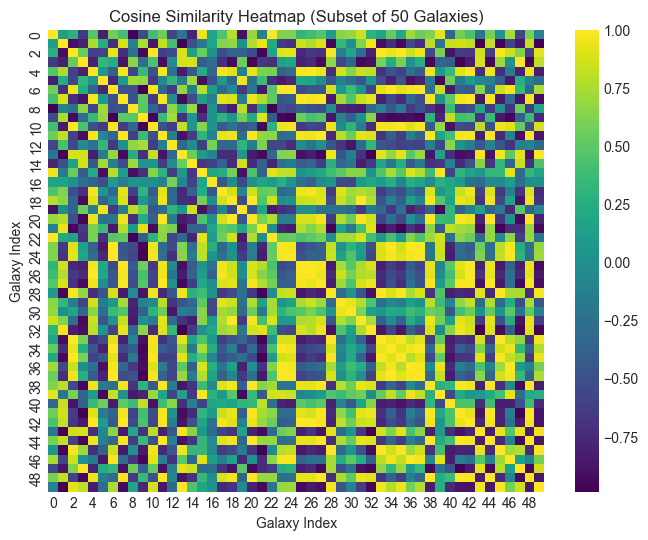

In [5]:
#create new clean dataframe with aligned columns between X and y
cols = ['SPECTROFLUX_U', 
    'SPECTROFLUX_G', 
    'SPECTROFLUX_R', 
    'SPECTROFLUX_I', 
    'SPECTROFLUX_Z',
    'VDISP',
    'Z']

#filter and split dataframe
cdf = df[cols].dropna()
x_df = cdf.drop(columns = ['Z'])
y = cdf['Z'].values
X = x_df.values

print(f"Clean Data Matrix X shape: {X.shape}")
print(f"Clean Target Vector y shape: {y.shape}")

#select subset of 50 objects
X_subset = X[:50]

#compute cosine similarity and standardise first so features with larger magnitudes dont dominate the angle
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_subset)
similarity_matrix = cosine_similarity(X_scaled)

#plot the heatmap
plt.figure(figsize = (8, 6))
sns.heatmap(similarity_matrix, cmap = 'viridis', annot = False)
plt.title('Cosine Similarity Heatmap (Subset of 50 Galaxies)')
plt.xlabel('Galaxy Index')
plt.ylabel('Galaxy Index')
plt.show()

### 3.3 Descriptive Statistics
Computing the mean, median, variance, and standard deviation for each continuous feature in the cleaned matrix.

In [ ]:
#compute these statistics across numerical dataframe
stats = x_df.describe().T[['mean', '50%', 'std']]
stats.rename(columns = {'50%': 'median', 'std': 'std_dev'}, inplace = True)

#add variance (std_dev squared)
stats['variance'] = x_df.var()

display(stats)

,mean,median,std_dev,variance
SPECTROFLUX_U,8.028812,3.099329,19.158753,367.057798
SPECTROFLUX_G,19.891026,7.600237,45.735016,2091.691697
SPECTROFLUX_R,41.583450,17.174947,84.823143,7194.965625
SPECTROFLUX_I,60.281576,27.472820,115.997096,13455.326372
SPECTROFLUX_Z,76.689227,35.191505,146.047003,21329.727150
VDISP,114.511491,91.120647,146.445438,21446.266242


**Observations and Comments (3.3):**
* Based on the statistics shown above, the photometric flux bands (like `SPECTROFLUX_R` and `SPECTROFLUX_G`) have different scales and variances. Because flux is measured linearly, very bright galaxies will cause these distributions to have high variance.
* The spectral feature, `VDISP` (Velocity Dispersion), represents the internal kinematics of the galaxies. Comparing its mean and median will expose if the sample is dominated by standard-mass galaxies or if it is skewed by a few incredibly large ones.

### 3.4 Visualisation
Visualizing individual distributions of the features and their pairwise relationships, including how they correlate with the chosen target variable, redshift ($Z$).